<a href="https://colab.research.google.com/github/AthiraPG-3/H1B_Visa_Prediction/blob/main/H1_B_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from statistics import mode
import re
from xgboost import XGBClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/h1b_kaggle.csv.zip')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3002458 entries, 0 to 3002457
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Unnamed: 0          int64  
 1   CASE_STATUS         object 
 2   EMPLOYER_NAME       object 
 3   SOC_NAME            object 
 4   JOB_TITLE           object 
 5   FULL_TIME_POSITION  object 
 6   PREVAILING_WAGE     float64
 7   YEAR                float64
 8   WORKSITE            object 
 9   lon                 float64
 10  lat                 float64
dtypes: float64(4), int64(1), object(6)
memory usage: 252.0+ MB


In [ ]:
df.head()

,Unnamed: 0,CASE_STATUS,EMPLOYER_NAME,SOC_NAME,JOB_TITLE,FULL_TIME_POSITION,PREVAILING_WAGE,YEAR,WORKSITE,lon,lat
0,1,CERTIFIED-WITHDRAWN,UNIVERSITY OF MICHIGAN,BIOCHEMISTS AND BIOPHYSICISTS,POSTDOCTORAL RESEARCH FELLOW,N,36067.0,2016.0,"ANN ARBOR, MICHIGAN",-83.743038,42.280826
1,2,CERTIFIED-WITHDRAWN,"GOODMAN NETWORKS, INC.",CHIEF EXECUTIVES,CHIEF OPERATING OFFICER,Y,242674.0,2016.0,"PLANO, TEXAS",-96.698886,33.019843
2,3,CERTIFIED-WITHDRAWN,"PORTS AMERICA GROUP, INC.",CHIEF EXECUTIVES,CHIEF PROCESS OFFICER,Y,193066.0,2016.0,"JERSEY CITY, NEW JERSEY",-74.077642,40.728158
3,4,CERTIFIED-WITHDRAWN,"GATES CORPORATION, A WHOLLY-OWNED SUBSIDIARY O...",CHIEF EXECUTIVES,"REGIONAL PRESIDEN, AMERICAS",Y,220314.0,2016.0,"DENVER, COLORADO",-104.990251,39.739236
4,5,WITHDRAWN,PEABODY INVESTMENTS CORP.,CHIEF EXECUTIVES,PRESIDENT MONGOLIA AND INDIA,Y,157518.4,2016.0,"ST. LOUIS, MISSOURI",-90.199404,38.627003


In [ ]:
df.describe()

,Unnamed: 0,PREVAILING_WAGE,YEAR,lon,lat
count,3.002458e+06,3.002373e+06,3.002445e+06,2.895216e+06,2.895216e+06
mean,1.501230e+06,1.469984e+05,2.013855e+03,-9.213441e+01,3.816054e+01
std,8.667351e+05,5.287609e+06,1.680612e+00,1.965591e+01,4.672835e+00
min,1.000000e+00,0.000000e+00,2.011000e+03,-1.578583e+02,1.343719e+01
25%,7.506152e+05,5.437100e+04,2.012000e+03,-1.119261e+02,3.416536e+01
50%,1.501230e+06,6.502100e+04,2.014000e+03,-8.615862e+01,3.910312e+01
75%,2.251844e+06,8.143200e+04,2.015000e+03,-7.551381e+01,4.088374e+01
max,3.002458e+06,6.997607e+09,2.016000e+03,1.457298e+02,6.483778e+01


In [ ]:
df['CASE_STATUS'].unique()

array(['CERTIFIED-WITHDRAWN', 'WITHDRAWN', 'CERTIFIED', 'DENIED',
       'REJECTED', 'INVALIDATED',
       'PENDING QUALITY AND COMPLIANCE REVIEW - UNASSIGNED', nan],
      dtype=object)

In [ ]:
#To convert the problem as a two class problem
import warnings
warnings.filterwarnings("ignore")
df.CASE_STATUS[df['CASE_STATUS']=='REJECTED'] = 'DENIED'
df.CASE_STATUS[df['CASE_STATUS']=='INVALIDATED'] = 'DENIED'
df.CASE_STATUS[df['CASE_STATUS']=='PENDING QUALITY AND COMPLIANCE REVIEW - UNASSIGNED'] = 'DENIED'
df.CASE_STATUS[df['CASE_STATUS']=='CERTIFIED-WITHDRAWN'] = 'CERTIFIED'
df.shape

(3002458, 11)

In [ ]:
df['CASE_STATUS'].unique()

array(['CERTIFIED', 'WITHDRAWN', 'DENIED', nan], dtype=object)

In [ ]:
print(df.EMPLOYER_NAME.describe())

count             3002399
unique             236013
top       INFOSYS LIMITED
freq               130592
Name: EMPLOYER_NAME, dtype: object


In [ ]:
df = df.drop(df[df.CASE_STATUS == 'WITHDRAWN'].index)

In [ ]:
df.shape

(2912659, 11)

In [ ]:
print(df['CASE_STATUS'].unique())

['CERTIFIED' 'DENIED' nan]


In [ ]:
## Storing non null in df w.r.t. case status

df = df.dropna(subset=['CASE_STATUS'])
print(df['CASE_STATUS'].value_counts())

CASE_STATUS
CERTIFIED    2818282
DENIED         94364
Name: count, dtype: int64


In [ ]:
#check count of NAN
count_nan = len(df) - df.count()
print(count_nan)

Unnamed: 0                 0
CASE_STATUS                0
EMPLOYER_NAME             18
SOC_NAME               17073
JOB_TITLE                 10
FULL_TIME_POSITION         1
PREVAILING_WAGE           53
YEAR                       0
WORKSITE                   0
lon                   102844
lat                   102844
dtype: int64


In [ ]:
#filling the missing values in EMPLOYER_NAME using mode (as it is an catedorical data)
df['EMPLOYER_NAME'] = df['EMPLOYER_NAME'].fillna(df['EMPLOYER_NAME'].mode()[0])
assert pd.notnull(df['EMPLOYER_NAME']).all().all()

In [ ]:
##to check the percentile in wages
print(np.nanpercentile(df.PREVAILING_WAGE,98))
print(df.PREVAILING_WAGE.median())
print(np.nanpercentile(df.PREVAILING_WAGE,2))#this wont't be used because we use impution

138611.0
65000.0
34028.8


In [ ]:
#using imputation to handle outliers

# Identify outliers using the IQR method
Q1 = df['PREVAILING_WAGE'].quantile(0.25)
Q3 = df['PREVAILING_WAGE'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Replace outliers with NaN
df.loc[df['PREVAILING_WAGE'] < lower_bound, 'PREVAILING_WAGE'] = np.nan
df.loc[df['PREVAILING_WAGE'] > upper_bound, 'PREVAILING_WAGE'] = np.nan

# Impute missing values (including outliers replaced with NaN) using the median
df['PREVAILING_WAGE'].fillna(df['PREVAILING_WAGE'].median(), inplace=True)


In [ ]:
## Filling na in JOB_TITLE and FULL_TIME_POSITION with mode
df['JOB_TITLE'] = df['JOB_TITLE'].fillna(df['JOB_TITLE'].mode()[0])
df['FULL_TIME_POSITION'] = df['FULL_TIME_POSITION'].fillna(df['FULL_TIME_POSITION'].mode()[0])
df['SOC_NAME'] = df['SOC_NAME'].fillna(df['SOC_NAME'].mode()[0])

In [ ]:
#check count of NAN
count_nan = len(df) - df.count()
print(count_nan)

Unnamed: 0                 0
CASE_STATUS                0
EMPLOYER_NAME              0
SOC_NAME                   0
JOB_TITLE                  0
FULL_TIME_POSITION         0
PREVAILING_WAGE            0
YEAR                       0
WORKSITE                   0
lon                   102844
lat                   102844
dtype: int64


In [ ]:
# Percentage of jobs applied for full-time jobs using value_counts()

full_time_percentage = df['FULL_TIME_POSITION'].value_counts(normalize=True)['Y'] * 100
print(f"Percentage of full-time job applications: {full_time_percentage:.2f}%")

Percentage of full-time job applications: 85.87%


In [ ]:
# Dropping lat and lon columns
df = df.drop('lat', axis = 1)
df = df.drop('lon', axis = 1)

In [ ]:
df.head()

,Unnamed: 0,CASE_STATUS,EMPLOYER_NAME,SOC_NAME,JOB_TITLE,FULL_TIME_POSITION,PREVAILING_WAGE,YEAR,WORKSITE
0,1,CERTIFIED,UNIVERSITY OF MICHIGAN,BIOCHEMISTS AND BIOPHYSICISTS,POSTDOCTORAL RESEARCH FELLOW,N,36067.0,2016.0,"ANN ARBOR, MICHIGAN"
1,2,CERTIFIED,"GOODMAN NETWORKS, INC.",CHIEF EXECUTIVES,CHIEF OPERATING OFFICER,Y,63918.0,2016.0,"PLANO, TEXAS"
2,3,CERTIFIED,"PORTS AMERICA GROUP, INC.",CHIEF EXECUTIVES,CHIEF PROCESS OFFICER,Y,63918.0,2016.0,"JERSEY CITY, NEW JERSEY"
3,4,CERTIFIED,"GATES CORPORATION, A WHOLLY-OWNED SUBSIDIARY O...",CHIEF EXECUTIVES,"REGIONAL PRESIDEN, AMERICAS",Y,63918.0,2016.0,"DENVER, COLORADO"
5,6,CERTIFIED,BURGER KING CORPORATION,CHIEF EXECUTIVES,"EXECUTIVE V P, GLOBAL DEVELOPMENT AND PRESIDEN...",Y,63918.0,2016.0,"MIAMI, FLORIDA"


In [ ]:
df.shape

(2912646, 9)

In [ ]:
#New feature creation

df['NEW_EMPLOYER'] = np.where(df['EMPLOYER_NAME'].str.lower().str.contains('university'), 'university', 'non university')

In [ ]:
df.shape

(2912646, 10)

In [ ]:
df['NEW_EMPLOYER']

,NEW_EMPLOYER
0,university
1,non university
2,non university
3,non university
5,non university
...,...
3002369,non university
3002378,non university
3002383,non university
3002389,non university


In [ ]:
# Creating occupation and mapping the values
warnings.filterwarnings("ignore")
df['OCCUPATION'] = np.nan
df['SOC_NAME'] = df['SOC_NAME'].str.lower()
df.OCCUPATION[df['SOC_NAME'].str.contains('computer','programmer')] = 'computer occupations'
df.OCCUPATION[df['SOC_NAME'].str.contains('software','web developer')] = 'computer occupations'
df.OCCUPATION[df['SOC_NAME'].str.contains('database')] = 'computer occupations'
df.OCCUPATION[df['SOC_NAME'].str.contains('math','statistic')] = 'Mathematical Occupations'
df.OCCUPATION[df['SOC_NAME'].str.contains('predictive model','stats')] = 'Mathematical Occupations'
df.OCCUPATION[df['SOC_NAME'].str.contains('teacher','linguist')] = 'Education Occupations'
df.OCCUPATION[df['SOC_NAME'].str.contains('professor','Teach')] = 'Education Occupations'
df.OCCUPATION[df['SOC_NAME'].str.contains('school principal')] = 'Education Occupations'
df.OCCUPATION[df['SOC_NAME'].str.contains('medical','doctor')] = 'Medical Occupations'
df.OCCUPATION[df['SOC_NAME'].str.contains('physician','dentist')] = 'Medical Occupations'
df.OCCUPATION[df['SOC_NAME'].str.contains('Health','Physical Therapists')] = 'Medical Occupations'
df.OCCUPATION[df['SOC_NAME'].str.contains('surgeon','nurse')] = 'Medical Occupations'
df.OCCUPATION[df['SOC_NAME'].str.contains('psychiatr')] = 'Medical Occupations'
df.OCCUPATION[df['SOC_NAME'].str.contains('chemist','physicist')] = 'Advance Sciences'
df.OCCUPATION[df['SOC_NAME'].str.contains('biology','scientist')] = 'Advance Sciences'
df.OCCUPATION[df['SOC_NAME'].str.contains('biologi','clinical research')] = 'Advance Sciences'
df.OCCUPATION[df['SOC_NAME'].str.contains('public relation','manage')] = 'Management Occupation'
df.OCCUPATION[df['SOC_NAME'].str.contains('management','operation')] = 'Management Occupation'
df.OCCUPATION[df['SOC_NAME'].str.contains('chief','plan')] = 'Management Occupation'
df.OCCUPATION[df['SOC_NAME'].str.contains('executive')] = 'Management Occupation'
df.OCCUPATION[df['SOC_NAME'].str.contains('advertis','marketing')] = 'Marketing Occupation'
df.OCCUPATION[df['SOC_NAME'].str.contains('promotion','market research')] = 'Marketing Occupation'
df.OCCUPATION[df['SOC_NAME'].str.contains('business','business analyst')] = 'Business Occupation'
df.OCCUPATION[df['SOC_NAME'].str.contains('business systems analyst')] = 'Business Occupation'
df.OCCUPATION[df['SOC_NAME'].str.contains('accountant','finance')] = 'Financial Occupation'
df.OCCUPATION[df['SOC_NAME'].str.contains('financial')] = 'Financial Occupation'
df.OCCUPATION[df['SOC_NAME'].str.contains('engineer','architect')] = 'Architecture & Engineering'
df.OCCUPATION[df['SOC_NAME'].str.contains('surveyor','carto')] = 'Architecture & Engineering'
df.OCCUPATION[df['SOC_NAME'].str.contains('technician','drafter')] = 'Architecture & Engineering'
df.OCCUPATION[df['SOC_NAME'].str.contains('information security','information tech')] = 'Architecture & Engineering'
df['OCCUPATION']= df.OCCUPATION.replace(np.nan, 'Others', regex=True)

In [ ]:
df.head()

,Unnamed: 0,CASE_STATUS,EMPLOYER_NAME,SOC_NAME,JOB_TITLE,FULL_TIME_POSITION,PREVAILING_WAGE,YEAR,WORKSITE,NEW_EMPLOYER,OCCUPATION
0,1,CERTIFIED,UNIVERSITY OF MICHIGAN,biochemists and biophysicists,POSTDOCTORAL RESEARCH FELLOW,N,36067.0,2016.0,"ANN ARBOR, MICHIGAN",university,Advance Sciences
1,2,CERTIFIED,"GOODMAN NETWORKS, INC.",chief executives,CHIEF OPERATING OFFICER,Y,63918.0,2016.0,"PLANO, TEXAS",non university,Management Occupation
2,3,CERTIFIED,"PORTS AMERICA GROUP, INC.",chief executives,CHIEF PROCESS OFFICER,Y,63918.0,2016.0,"JERSEY CITY, NEW JERSEY",non university,Management Occupation
3,4,CERTIFIED,"GATES CORPORATION, A WHOLLY-OWNED SUBSIDIARY O...",chief executives,"REGIONAL PRESIDEN, AMERICAS",Y,63918.0,2016.0,"DENVER, COLORADO",non university,Management Occupation
5,6,CERTIFIED,BURGER KING CORPORATION,chief executives,"EXECUTIVE V P, GLOBAL DEVELOPMENT AND PRESIDEN...",Y,63918.0,2016.0,"MIAMI, FLORIDA",non university,Management Occupation


In [ ]:
# Splitting city and state and capturing state in another variable. str[-1] to select the last word
df['state'] = df.WORKSITE.str.split('\s+').str[-1]
df.head()

,Unnamed: 0,CASE_STATUS,EMPLOYER_NAME,SOC_NAME,JOB_TITLE,FULL_TIME_POSITION,PREVAILING_WAGE,YEAR,WORKSITE,NEW_EMPLOYER,OCCUPATION,state
0,1,CERTIFIED,UNIVERSITY OF MICHIGAN,biochemists and biophysicists,POSTDOCTORAL RESEARCH FELLOW,N,36067.0,2016.0,"ANN ARBOR, MICHIGAN",university,Advance Sciences,MICHIGAN
1,2,CERTIFIED,"GOODMAN NETWORKS, INC.",chief executives,CHIEF OPERATING OFFICER,Y,63918.0,2016.0,"PLANO, TEXAS",non university,Management Occupation,TEXAS
2,3,CERTIFIED,"PORTS AMERICA GROUP, INC.",chief executives,CHIEF PROCESS OFFICER,Y,63918.0,2016.0,"JERSEY CITY, NEW JERSEY",non university,Management Occupation,JERSEY
3,4,CERTIFIED,"GATES CORPORATION, A WHOLLY-OWNED SUBSIDIARY O...",chief executives,"REGIONAL PRESIDEN, AMERICAS",Y,63918.0,2016.0,"DENVER, COLORADO",non university,Management Occupation,COLORADO
5,6,CERTIFIED,BURGER KING CORPORATION,chief executives,"EXECUTIVE V P, GLOBAL DEVELOPMENT AND PRESIDEN...",Y,63918.0,2016.0,"MIAMI, FLORIDA",non university,Management Occupation,FLORIDA


In [ ]:
df.shape

(2912646, 12)

In [ ]:
#convert the target classes to binary, i.e. 0 and 1.
from sklearn import preprocessing
# creating a dict file
class_mapping = {'CERTIFIED':0, 'DENIED':1}
df["CASE_STATUS"] = df["CASE_STATUS"].map(class_mapping)


In [ ]:
print(df.head(7))

   Unnamed: 0  CASE_STATUS                                      EMPLOYER_NAME  \
0           1            0                             UNIVERSITY OF MICHIGAN   
1           2            0                             GOODMAN NETWORKS, INC.   
2           3            0                          PORTS AMERICA GROUP, INC.   
3           4            0  GATES CORPORATION, A WHOLLY-OWNED SUBSIDIARY O...   
5           6            0                            BURGER KING CORPORATION   
6           7            0                   BT AND MK ENERGY AND COMMODITIES   
7           8            0                    GLOBO MOBILE TECHNOLOGIES, INC.   

                        SOC_NAME  \
0  biochemists and biophysicists   
1               chief executives   
2               chief executives   
3               chief executives   
5               chief executives   
6               chief executives   
7               chief executives   

                                           JOB_TITLE FULL_TIME

In [ ]:
#To see the different Job Title as a one dimensional array
test1 = pd.Series(df['JOB_TITLE'].ravel()).unique()
print(pd.DataFrame(test1))

                                                        0
0                            POSTDOCTORAL RESEARCH FELLOW
1                                 CHIEF OPERATING OFFICER
2                                   CHIEF PROCESS OFFICER
3                             REGIONAL PRESIDEN, AMERICAS
4       EXECUTIVE V P, GLOBAL DEVELOPMENT AND PRESIDEN...
...                                                   ...
284544                              DFT MODELING ENGINEER
284545      SENIOR SOFTWARE ENGINEER (LTE PROTOCOL STACK)
284546                       CHEMISTRY  - SCIENCE TEACHER
284547                         SALES AND LOGISTIC MANAGER
284548                            APPRAISERS, REAL ESTATE

[284549 rows x 1 columns]


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2912646 entries, 0 to 3002392
Data columns (total 12 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Unnamed: 0          int64  
 1   CASE_STATUS         int64  
 2   EMPLOYER_NAME       object 
 3   SOC_NAME            object 
 4   JOB_TITLE           object 
 5   FULL_TIME_POSITION  object 
 6   PREVAILING_WAGE     float64
 7   YEAR                float64
 8   WORKSITE            object 
 9   NEW_EMPLOYER        object 
 10  OCCUPATION          object 
 11  state               object 
dtypes: float64(2), int64(2), object(8)
memory usage: 288.9+ MB


In [ ]:
#dropping irrelevant or redundant columns for feature selection / engineering , dimensionality reduction or for data privacy
df = df.drop('EMPLOYER_NAME', axis = 1)
df = df.drop('SOC_NAME', axis = 1)
df = df.drop('JOB_TITLE', axis = 1)
df = df.drop('WORKSITE', axis = 1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2912646 entries, 0 to 3002392
Data columns (total 8 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Unnamed: 0          int64  
 1   CASE_STATUS         int64  
 2   FULL_TIME_POSITION  object 
 3   PREVAILING_WAGE     float64
 4   YEAR                float64
 5   NEW_EMPLOYER        object 
 6   OCCUPATION          object 
 7   state               object 
dtypes: float64(2), int64(2), object(4)
memory usage: 200.0+ MB


In [ ]:
df.shape

(2912646, 8)

In [ ]:
#creating a copy of the dataframe
df1 = df.copy()

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2912646 entries, 0 to 3002392
Data columns (total 8 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Unnamed: 0          int64  
 1   CASE_STATUS         int64  
 2   FULL_TIME_POSITION  object 
 3   PREVAILING_WAGE     float64
 4   YEAR                float64
 5   NEW_EMPLOYER        object 
 6   OCCUPATION          object 
 7   state               object 
dtypes: float64(2), int64(2), object(4)
memory usage: 200.0+ MB


In [ ]:
df1.shape

(2912646, 8)

In [ ]:
df1.head()

,Unnamed: 0,CASE_STATUS,FULL_TIME_POSITION,PREVAILING_WAGE,YEAR,NEW_EMPLOYER,OCCUPATION,state
0,1,0,N,36067.0,2016.0,university,Advance Sciences,MICHIGAN
1,2,0,Y,63918.0,2016.0,non university,Management Occupation,TEXAS
2,3,0,Y,63918.0,2016.0,non university,Management Occupation,JERSEY
3,4,0,Y,63918.0,2016.0,non university,Management Occupation,COLORADO
5,6,0,Y,63918.0,2016.0,non university,Management Occupation,FLORIDA


In [ ]:
print(df1['CASE_STATUS'].value_counts())

CASE_STATUS
0    2818282
1      94364
Name: count, dtype: int64


In [ ]:
#Defining feature and target
X = df.drop('CASE_STATUS', axis=1) #features (except the label CASE_STATUS)
y = df.CASE_STATUS #label

##imbalance handling


In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
##Handle class imbalance using SMOTE on the training data (after encoding
smote = SMOTE(random_state=42)

In [ ]:
# Assuming X contains categorical features, encode them before applying SMOTE
X_encoded = pd.get_dummies(X,
                           columns=['FULL_TIME_POSITION', 'NEW_EMPLOYER',
                                    'OCCUPATION', 'state'],
                           drop_first=True) # Optional: drop_first to avoid multicollinearity

# Now apply SMOTE to the encoded data
X_resampled, y_resampled = smote.fit_resample(X_encoded, y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.40, random_state=42)

In [ ]:
#check for any class imbalance after smot
print(pd.Series(y_resampled).value_counts())


CASE_STATUS
0    2818282
1    2818282
Name: count, dtype: int64


##Training


###TRAINING USING xgbosst

In [ ]:
# Convert the resampled dataset to a matrix format using to_numpy()
train_X = X_train.to_numpy()  # Use resampled data
train_y = y_train.to_numpy()  # Use resampled data


In [ ]:
import xgboost
gbm=xgboost.XGBClassifier(max_features='sqrt', subsample=0.8, random_state=10)

In [ ]:
#Using GridSearchCV() to tune hyperparameters:
from sklearn.model_selection import GridSearchCV

n_estimators: Controls the number of boosting trees (or rounds) in the XGBoost model.
[10, 100]: The code will test the model's performance with 10 and 100 estimators.

In [ ]:
parameters = [{'n_estimators': [10, 100]},
              {'learning_rate': [0.1,0.01,0.5]}]

In [ ]:
#to find the best hyperparameters for a machine learning model(XGBClassifier)
grid_search = GridSearchCV(estimator = gbm, param_grid = parameters, scoring='accuracy', cv = 3, n_jobs=-1)

In [ ]:
#finding the best-performing XGBoost model, ready to be used for making predictions on new data.
grid_search = grid_search.fit(X_train, y_train)

In [ ]:
grid_search.best_params_, grid_search.best_score_

({'learning_rate': 0.5}, np.float64(0.9455605040031388))

In [ ]:
grid_search.best_estimator_

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.5, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_features='sqrt', max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=None, n_jobs=None, ...)

In [ ]:
XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
 colsample_bytree=1, gamma=0, learning_rate=0.5, max_delta_step=0,
 max_depth=3, max_features='sqrt', min_child_weight=1, missing=None,
 n_estimator=100, n_jobs=1, nthread=None,
 objective='binary:logistic', random_state=10, reg_alpha=0,
 reg_lambda=1, scale_pos_weight=1, seed=None, silent=True,
 subsample=0.8)

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.5, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=0,
              max_depth=3, max_features='sqrt', max_leaves=None,
              min_child_weight=1, missing=None, monotone_constraints=None,
              multi_strategy=None, n_estimator=100, n_estimators=None, ...)

In [ ]:
gbm=xgboost.XGBClassifier(base_score=0.5,
 booster='gbtree', colsample_bylevel=1,
 colsample_bytree=1, gamma=0, learning_rate=0.5,
 max_delta_step=0, max_depth=3, max_features='sqrt',
 min_child_weight=1, missing=np.nan,
 n_estimator=100, n_jobs=1, nthread=None,
 objective='binary:logistic', random_state=10, reg_alpha=0,
 reg_lambda=1, scale_pos_weight=1, seed=None,
 silent=True, subsample=0.8).fit(X_train,y_train)

In [ ]:
# Before predicting, ensure X_test has the same columns as X_train:
missing_cols = set(X_train.columns) - set(X_test.columns)
for col in missing_cols:
    X_test[col] = 0  # Add missing columns to X_test and fill with 0

# Reorder X_test columns to match X_train:
X_test = X_test[X_train.columns]




In [ ]:
# Now predict:
y_pred = gbm.predict(X_test)

In [ ]:
gbm=xgboost.XGBClassifier(base_score=0.5,
 booster='gbtree', colsample_bylevel=1,
 colsample_bytree=1, gamma=0, learning_rate=0.5,
 max_delta_step=0, max_depth=3, max_features='sqrt',
 min_child_weight=1, missing=np.nan,
 n_estimator=100, n_jobs=1, nthread=None,
 objective='binary:logistic', random_state=10, reg_alpha=0,
 reg_lambda=1, scale_pos_weight=1, seed=None,
 silent=True, subsample=0.8).fit(X_train,y_train)

In [ ]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1115504   11379]
 [ 140393  987350]]
              precision    recall  f1-score   support

           0       0.89      0.99      0.94   1126883
           1       0.99      0.88      0.93   1127743

    accuracy                           0.93   2254626
   macro avg       0.94      0.93      0.93   2254626
weighted avg       0.94      0.93      0.93   2254626



In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred)

np.float64(0.932705995923665)

0.932705995923665


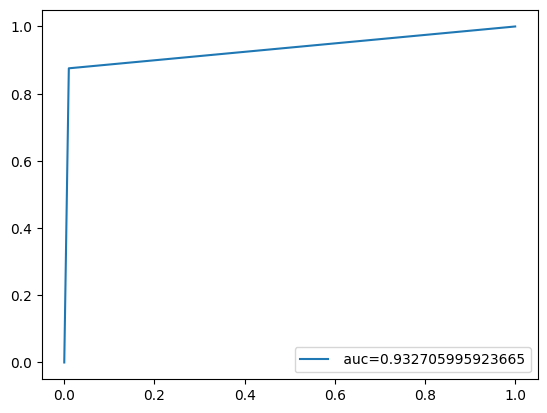

In [ ]:
from sklearn import metrics
import matplotlib.pyplot as plt

fpr_xg, tpr_xg, thresholds = metrics.roc_curve(y_test, y_pred)
print(metrics.auc(fpr_xg, tpr_xg))
auc_xgb = np.trapz(tpr_xg,fpr_xg)
plt.plot(fpr_xg,tpr_xg,label=" auc="+str(auc_xgb))
plt.legend(loc=4)
plt.show()

In [ ]:
import pickle

"""Saving the Model"""
XGB_Model_h1b = 'XGB_Model_hlb.sav'


In [ ]:
pickle.dump(gbm, open(XGB_Model_h1b, "wb"))

In [ ]:
 # Load the saved model
loaded_model = pickle.load(open(XGB_Model_h1b, 'rb'))

In [ ]:
import pandas as pd
import numpy as np
import pickle

# Example of getting user input
prevailing_wage = float(input("Enter the prevailing wage: "))
full_time_position = input("Is it a full-time position? (Y/N): ")
employer_type = input("Is the employer a university? (university/non university): ")
occupation = input("Enter the occupation: ")
state = input("Enter the state: ")

# Create a dictionary from user input
user_data = {
        # Include 'Unnamed: 0' and 'YEAR' with placeholder values
        'Unnamed: 0': [0],  # Placeholder, as this seems to be an index from original data
        'PREVAILING_WAGE': [prevailing_wage],
        'YEAR': [2016], # Assuming 2016 as a common year from the dataset
        'FULL_TIME_POSITION': [full_time_position],
        'NEW_EMPLOYER': [employer_type],
        'OCCUPATION': [occupation],
        'state': [state]
    }

# Create a DataFrame from the user data
user_df = pd.DataFrame(user_data)

# Re-load the model to access the feature names it expects
loaded_model = pickle.load(open(XGB_Model_h1b, 'rb'))

# Get the exact column names from the trained model's expected features
# The model stores the feature names it was trained on
training_columns_from_model = loaded_model.get_booster().feature_names

# Ensure that the user input DataFrame has all the columns that the model expects.
# We will create dummy variables for the categorical columns in the user input.
# Then, we will reindex this DataFrame to match the columns of the training data
# and fill any missing columns (categories not present in the user input but in training) with 0.

# Perform one-hot encoding on the user input data frame
# We cannot use the same columns list as used for get_dummies during training directly
# because get_dummies creates columns based on the unique values in the current dataframe.
# Instead, we will perform get_dummies on the user input and then reindex.
user_df_encoded = pd.get_dummies(user_df, columns=['FULL_TIME_POSITION', 'NEW_EMPLOYER', 'OCCUPATION', 'state'])


# Reindex the user input DataFrame to match the exact columns of the training data.
# This adds any missing columns with a fill_value of 0 and orders the columns correctly.
user_df_aligned = user_df_encoded.reindex(columns=training_columns_from_model, fill_value=0)

# Make a prediction using the loaded model
prediction = loaded_model.predict(user_df_aligned)

# Interpret the prediction
if prediction[0] == 0:
    print("Based on the input, the case is predicted to be CERTIFIED.")
else:
    print("Based on the input, the case is predicted to be DENIED.")